<a href="https://colab.research.google.com/github/hussainsakinah/Neural-Networks-From-Scratch/blob/main/micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

20.0

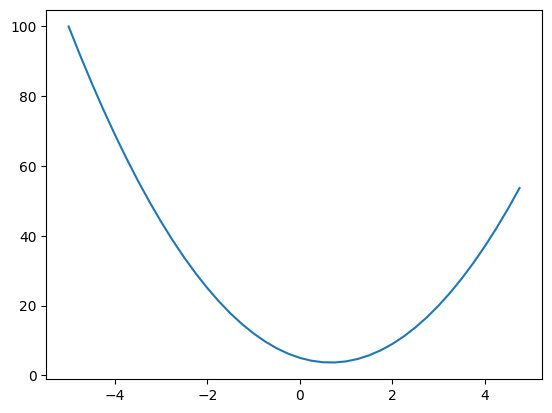

In [ ]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.000001
x = 2/3
(f(x+h) - f(x)) / h

2.999378523327323e-06

In [ ]:
#increasing complexity
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
#understanding derivatives

h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
#implementing a neural net

class Value:
  #The double underscore methods are dunder methods
  # They're hooks that Python calls automatically when you use certain syntax or operators on your objects
  # a + b	implies a.__add__(b)
  # a - b implies a.__sub__(b)
  # a * b implies a.__mul__(b)

  # You can only "hook into" operators using Python's exact reserved dunder names
  # You can't invent your own dunder name and expect an operator to call it

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self): # The repr function lets us print in whatever form we want the data to be printed
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other),'+')
    return out

  # If you want * to work on your objects, it must be named __mul__, no exceptions.
  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other),'*')
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self, ), 'tanh')
    return out


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c #(a.__mul__(b)).__add__(c)
d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
print(L)

Value(data = -8.0)


In [ ]:
d._prev

{Value(data = -6.0), Value(data = 10.0)}

In [ ]:
d._op

'+'

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set() # initializing empty set for both nodes and edges
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular {'record'} node for it
    dot.node(name = uid, label="{ %s | data %.4f | %.4f }" % (n.label, n.data, n.grad), shape = 'record')
    if n._op:
      # if this value is a result of some operation, then create an op node for it
      dot.node(name=uid + n._op, label=n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

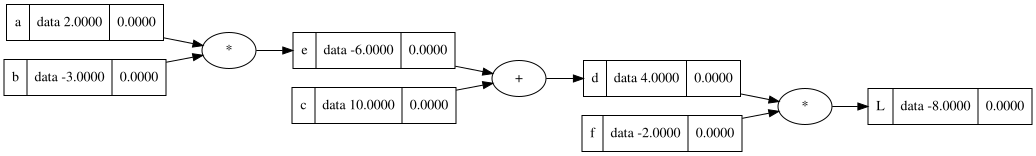

In [ ]:
draw_dot(L)

In [ ]:
L.grad = 1.0

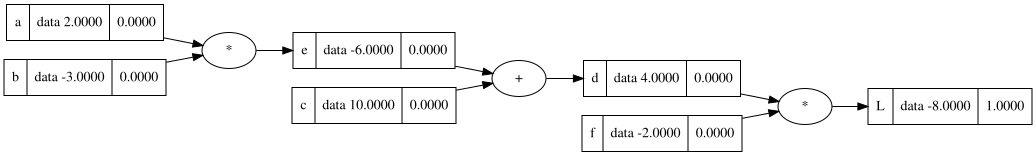

In [ ]:
draw_dot(L)

L = d * f

dL/dd = ? = f

(f(x+h)-f(x))/h

((d+h)*f - d*f)/h = f

dL/dd = f

dL/df  = d


---



In [ ]:
d.grad = -2.0
f.grad = 4.0

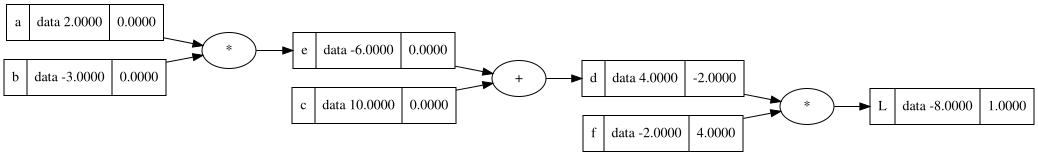

In [ ]:
draw_dot(L)



---


dd/dc = 1.0
de/dc = 1.0
d = c + e

**WHAT WE WANT:**

dL/de = (dL/dd) * (dd/de)

dL/dc = (dL/dd) * (dd/dc)

**WHAT WE KNOW:**

dL/dd

dd/de

dd/dc

In [ ]:
e.grad = -2.0
c.grad = -2.0

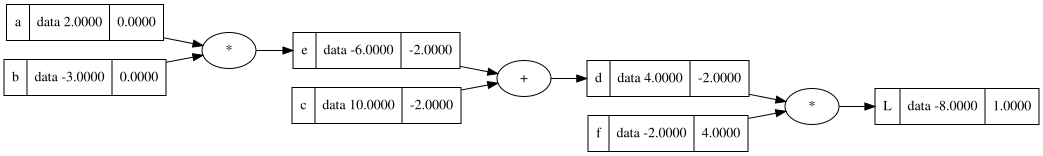

In [ ]:
draw_dot(L)

**WHAT WE WANT:**

dL/da = (dL/de) * (de/da)

dL/db = (dL/de) * (de/db)

**WHAT WE KNOW:**

dL/de = -2.0

de/da = b

de/db = a

In [ ]:
a.grad = -2.0*-3.0
b.grad = -2.0*2.0

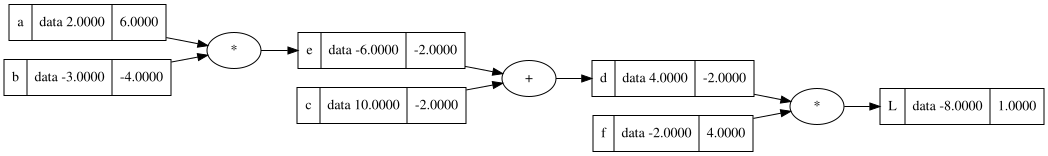

In [ ]:
draw_dot(L)

In [ ]:
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c #(a.__mul__(b)).__add__(c)
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0 + h, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  # e.data += h
  d = e + c
  # d.data += h
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2 - L1)/h)
lol()

-3.9999999999995595


In [ ]:
# nudging the inputs to optimize the loss
# 0.01 is the step
# we multiply the step with the gradient so that we move in the direction of the gradient
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

# we expect the loss to have reduced
print(L.data)

-7.286496


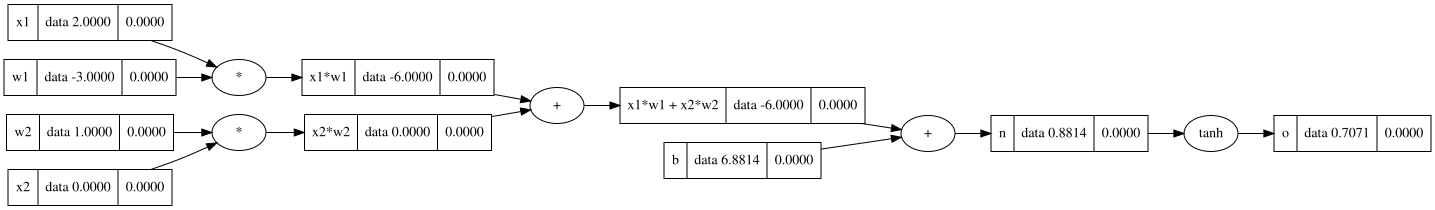

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label='o'

In [ ]:
o.grad = 1.0

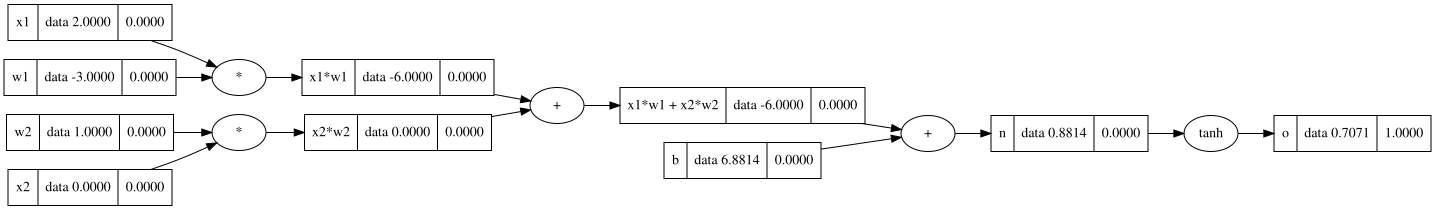

In [ ]:
draw_dot(o)